# Session 3: Hypothesis Testing and Regression Analysis
**Data Science Techniques and Real-World Applications &mdash; WS 2026**

**Zahra Sharafi**

**Frankfurt School of Finance and Management**

Thursday 17 September 2026 

Two questions drive today's agenda:
1. **One:** given a pattern in a sample, how do you decide it's real and put a number on it?
2. **Two:** even once you've done that carefully, does the pattern mean one thing *causes* the other?

We start with the logic of hypothesis testing, then show that a regression table is really a set of hypothesis
tests already run for you &mdash; the two topics are the same idea applied to a richer question.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

df = pd.read_excel("data/techstocks.xlsx", sheet_name="main")
df = df.rename(columns={"Return on the S&P 500 Index": "MktReturn"})
df.head()

,PERMNO,Names Date,Ticker Symbol,Company Name,Price or Bid/Ask Average,Returns,MktReturn
0,14542,2018-01-02,GOOG,ALPHABET INC,1065.000000,0.017775,0.008303
1,14542,2018-01-03,GOOG,ALPHABET INC,1082.479980,0.016413,0.006399
2,14542,2018-01-04,GOOG,ALPHABET INC,1086.400024,0.003621,0.004029
3,14542,2018-01-05,GOOG,ALPHABET INC,1102.229980,0.014571,0.007034
4,14542,2018-01-08,GOOG,ALPHABET INC,1106.939941,0.004273,0.001662


## <span style="color:#1e3a8a">Part 1: The logic of hypothesis testing</span>

A **hypothesis test** is a way of using sample data to make a decision about something you can't
observe directly &mdash; the true, underlying pattern in the whole population.

**Purpose:**
- Gather evidence from a dataset.
- Decide whether a claim about the population is plausible.
- Help distinguish a genuine effect from something that could easily be due to chance.

**Key idea:** compare the evidence in your data against a baseline assumption &mdash; you don't
prove your hypothesis directly; you ask "if the boring, no-effect explanation were true, how
surprising would this data be?"

## <span style="color:#1e3a8a">The steps</span>

**1. State the hypotheses**
- **Null hypothesis ($H_0$)**: no effect, no difference. The boring, default explanation.
- **Alternative hypothesis ($H_1$ or $H_A$)**: there is an effect or difference.

**2. Choose a significance level ($\alpha$)** &mdash; commonly 0.05 (a 5% tolerance for error).

**3. Select a test and calculate a test statistic** &mdash; t-test, chi-square, ANOVA, etc.,
depending on the question and the data.

**4. Apply the decision rule**
- If the *p*-value $< \alpha$: reject $H_0$ &mdash; the data would be quite surprising if $H_0$
  were true, so treat this as evidence *for* $H_1$.
- If the *p*-value $\geq \alpha$: do not reject $H_0$ &mdash; not enough evidence against it.
  (This is *not* the same as proving $H_0$ true &mdash; "not enough evidence" and "definitely no
  effect" are different claims.)

### What $\alpha$ looks like

$\alpha$ is a probability under the null distribution: the area in the tail(s) you've marked as
"too extreme to be believable if $H_0$ were true." Anything landing in that shaded area gets
rejected &mdash; that's why it's exactly a 5% chance of a false alarm when $\alpha = 0.05$.

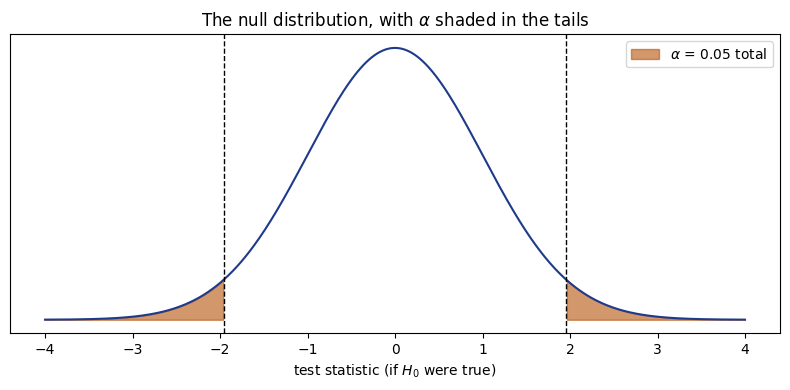

In [2]:
x = np.linspace(-4, 4, 500)
null_dist = stats.norm.pdf(x)
alpha = 0.05
crit = stats.norm.ppf(1 - alpha / 2)   # two-tailed critical value

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, null_dist, color="#1e3a8a")
ax.fill_between(x[x >= crit], null_dist[x >= crit], color="#b45309", alpha=0.6)
ax.fill_between(x[x <= -crit], null_dist[x <= -crit], color="#b45309", alpha=0.6, label=f"$\\alpha$ = {alpha} total")
for c in (-crit, crit):
    ax.axvline(c, color="black", linestyle="--", linewidth=1)
ax.set_title("The null distribution, with $\\alpha$ shaded in the tails")
ax.set_xlabel("test statistic (if $H_0$ were true)")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

## <span style="color:#1e3a8a">Outcomes and errors</span>

Whichever way a test comes out, it can be wrong in one of two distinct ways:

| | $H_0$ is actually true | $H_0$ is actually false |
|---|---|---|
| **Reject $H_0$** | Type I error (false positive), probability = $\alpha$ | Correct |
| **Fail to reject $H_0$** | Correct | Type II error (false negative), probability = $\beta$ |

- **Type I error**: concluding there's an effect when there really isn't (e.g. "this drug works" when it doesn't).
- **Type II error**: missing a real effect (e.g. "this drug doesn't work" when it actually does).
- $1 - \beta$ is called the **power** of the test &mdash; its ability to detect a real effect when one exists.  Power increases with larger sample size, bigger true effect size, or a less strict $\alpha$.

There's an inherent tension here: making a test more conservative (harder to reject $H_0$) lowers
your Type I error rate but raises your Type II error rate, and vice versa. Neither error can be
driven to zero at the same time. The only way to shrink both simultaneously is to collect more data (bigger sample), not by moving the threshold.

### Seeing the trade-off: a smoke detector

Think of $\alpha$ as a sensitivity dial on a smoke detector ($H_0$ = "no fire"). $\alpha$ *is* the
dial position: the probability the alarm goes off when there's no fire (a false alarm), so it's
set directly by how far you turn the dial.
- **Turn it down** ($\alpha$ small, e.g. 0.01): it rarely screams at burnt toast (few Type I
  errors) &mdash; but it might stay quiet during a real small fire (more Type II errors, lower
  power).
- **Turn it up** ($\alpha$ large, e.g. 0.10): it catches every real fire (high power) &mdash; but
  now it also screams at burnt toast more often (more false alarms, it alarms although nothing is going on, exactly $\alpha$ of the time).

No dial setting removes both problems at once. The only way to get fewer false alarms *and* catch
more real fires is a **better detector**: more data, or a more precise measurement, not a
different dial setting.

## <span style="color:#1e3a8a">The t-test</span>

The most common test for "is this average meaningfully different from some value (often zero), or
different between two groups?"

- Start by assuming $H_0$ is true: the parameter of interest equals 0.
- Collect evidence: is the estimated value ($\hat s$) close to 0, or far from it?
- The **t-statistic** measures "how far," in standard-error units:

$$t = \frac{\bar x}{SE(\bar x)} \qquad \text{(one-sample: is the mean 0?)}$$

$$t = \frac{\bar x_A - \bar x_B}{\sqrt{\dfrac{s_A^2}{n_A} + \dfrac{s_B^2}{n_B}}} \qquad \text{(two-sample: are the means equal?)}$$

where $s_A, s_B$ are each group's standard deviation and $n_A, n_B$ each group's sample size &mdash;
the denominator is just the SE of the *difference* between the two means.

`scipy.stats` computes both the t-statistic and the p-value for you &mdash; you rarely need to
compute either by hand.

---
<small>

**Standard Deviation (SD)**: Measures the natural scatter or variation of individual data points around a sample mean. It stays roughly the same size even if you collect more data.

**Standard Error (SE)**: Measures the precision or uncertainty of a sample estimate, such as how much a sample mean fluctuates from the true population mean. It shrinks as your sample size grows larger.
</small>

### One-sample t-test: is AAPL's average daily return actually different from zero?

In [3]:
aapl_returns = df[df["Ticker Symbol"] == "AAPL"]["Returns"]

t_stat, p_value = stats.ttest_1samp(aapl_returns, popmean=0)
print(f"mean return: {aapl_returns.mean():.5f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.4f}")

mean return: 0.00181
t-statistic: 2.250
p-value:     0.0248


The p-value is below 0.05, that's evidence AAPL's average daily return over this period was
not zero -- notice this says nothing about *why*, or whether it will continue; it's a statement about
this sample, evaluated against a specific null hypothesis.

### Two-sample t-test: is AAPL's average return different from GOOG's?

In [4]:
aapl = df[df["Ticker Symbol"] == "AAPL"]["Returns"]
goog = df[df["Ticker Symbol"] == "GOOG"]["Returns"]

t_stat, p_value = stats.ttest_ind(aapl, goog)
print(f"AAPL mean: {aapl.mean():.5f}   GOOG mean: {goog.mean():.5f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.4f}")

AAPL mean: 0.00181   GOOG mean: 0.00087
t-statistic: 0.878
p-value:     0.3801


### Testing a relationship: is AAPL's correlation with the market significant?

So far every test has asked about a single number (a mean, or a difference between two means). But
you can test a *relationship* the same way. `scipy.stats.pearsonr` returns both the correlation
coefficient and a p-value for $H_0$: the true correlation is 0.

In [5]:
aapl_mkt = df[df["Ticker Symbol"] == "AAPL"][["Returns", "MktReturn"]]

r, p_value = stats.pearsonr(aapl_mkt["Returns"], aapl_mkt["MktReturn"])
print(f"correlation: {r:.3f}")
print(f"p-value:     {p_value:.4g}")

correlation: 0.791
p-value:     3.802e-163


A correlation this strong and this significant is a *pattern* worth taking seriously. But "the
correlation isn't zero" is a fairly thin conclusion &mdash; it doesn't tell us *how much* AAPL moves
for a given market move, and it doesn't say the relationship is a straight line. That's exactly
what regression, in Part 2, will give us: a testable, interpretable number for the relationship
itself.

### Confidence intervals

A p-value answers "is this significant?" A **confidence interval** answers the arguably more useful
question: "what's a plausible *range* for the true value?" A 95% CI is the range of values that a
hypothesis test at $\alpha = 0.05$ would *not* reject.

In [6]:
ci = stats.t.interval(
    confidence=0.95,
    df=len(aapl_returns) - 1,
    loc=aapl_returns.mean(),
    scale=stats.sem(aapl_returns),   # standard error of the mean
)
print(f"95% CI for AAPL's mean daily return: ({ci[0]:.5f}, {ci[1]:.5f})")

95% CI for AAPL's mean daily return: (0.00023, 0.00339)


<span style="color:#b45309">**Exercise 1: Test another pair of tickers**</span>

Run a two-sample t-test comparing `Returns` for AMZN and NFLX. State the null hypothesis in words,
report the p-value, and say whether you'd reject $H_0$ at $\alpha = 0.05$. Then run a correlation
test (`stats.pearsonr`) between AMZN's `Returns` and `MktReturn`, and report whether the
correlation is significant.

Try it in the cell below, then check the answer notebook (`Session 3a - Exercise Answers.ipynb`).

In [7]:
# your code here


## <span style="color:#1e3a8a">A closing caution: testing many hypotheses at once</span>

If you run 20 independent hypothesis tests at $\alpha = 0.05$, you'd expect **about one of them to
come back "significant" by pure chance**, even if nothing real is going on anywhere. This is exactly
why it pays to be conservative about which hypotheses you test, and skeptical of a single significant
result buried among many tests that weren't reported.

This isn't a technicality &mdash; it's one of the most common ways a well-intentioned analysis
misleads. Keep it in mind for every case study this term: report what you tested, not just what
came out significant.

**Example:** an analyst screens 20 unrelated stocks for a "signal" &mdash; e.g. testing whether
each one's returns correlate with the phase of the moon. None of them actually do. But by pure
chance, about one of those 20 tests will come back with $p < 0.05$ anyway. If the analyst only
reports that one hit ("Stock X returns are linked to the moon phase, p=0.03!") and stays quiet
about the 19 that found nothing, it *looks* like a real discovery &mdash; it's just chance dressed
up as a finding.

This is exactly why *where a hypothesis comes from* matters as much as how you test it.

Exploratory Data Analysis (EDA) is a valid and useful way to generate hypotheses. Patterns found
during EDA &mdash; such as correlations, subgroup differences, or unusual trends &mdash; can
motivate questions for further investigation.

However, a hypothesis discovered from a dataset should be treated as exploratory, not as if it had
been specified in advance. Testing that hypothesis on the same data can lead to overly optimistic
p-values, because the data were used both to select and to test the hypothesis.

A clean workflow is:

**EDA &rarr; generate hypothesis &rarr; test on new or held-out data**

EDA itself is not p-hacking. Bekes & Kezdi's **p-hacking** is when an analyst searches across many
analyses, variables, or subsets and then presents a statistically significant result as though it
came from a pre-specified test. The key distinction is between exploratory hypothesis generation
and confirmatory hypothesis testing.

## <span style="color:#1e3a8a">Part 2: From testing to modeling</span>

Every test above answered a yes/no question about a single number. **Regression** asks a richer
question &mdash; "how does $y$ change as $x$ changes?" &mdash; and, as a bonus, it runs a hypothesis
test on the answer automatically. Once you can read a regression table, you already know how to
read the hypothesis test inside it: it's the same logic from Part 1.

### Simple linear regression: fitting a line

A simple linear regression models one outcome $y$ as a straight-line function of one predictor $x$:

$$y = \beta_0 + \beta_1 x + \varepsilon$$

- $\beta_0$ (the **intercept**) is the expected value of $y$ when $x = 0$.
- $\beta_1$ (the **slope**) is the expected change in $y$ for a one-unit increase in $x$.
- $\varepsilon$ (the **residual**, or error term) is everything about $y$ that $x$ doesn't explain.

Fitting the line means choosing $\hat\beta_0$ and $\hat\beta_1$ that make the residuals as small as
possible &mdash; specifically, **ordinary least squares (OLS)** minimizes the sum of *squared*
residuals. `statsmodels` does this for us.

### A market-model regression: how does AAPL move with the market?

This is a real, finance-standard use of simple regression: regressing a stock's daily return on
the market's daily return (here, the S&P 500) is exactly how a stock's **beta** is estimated.

In [9]:
aapl_full = df[df["Ticker Symbol"] == "AAPL"]

model_aapl = smf.ols("Returns ~ MktReturn", data=aapl_full).fit()
print(model_aapl.summary())

                            OLS Regression Results                            
Dep. Variable:                Returns   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     1262.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):          3.80e-163
Time:                        17:48:35   Log-Likelihood:                 2181.3
No. Observations:                 756   AIC:                            -4359.
Df Residuals:                     754   BIC:                            -4349.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0011      0.000      2.323      0.0

### Reading the table

- **`coef`** is $\hat\beta_0$ (`Intercept`) and $\hat\beta_1$ (`MktReturn`). Here `MktReturn`'s
  coefficient is AAPL's **beta**: roughly, for every 1% the market moves, AAPL moves about that
  coefficient times 1%. A beta above 1 means AAPL swings *more* than the market.

  <small>`coef` gives the slope (1.19): for each 1-unit increase in `MktReturn`,
  AAPL's `Returns` rises by 1.19 units on average. It's expressed in percent because both
  `Returns` and `MktReturn` are themselves returns &mdash; proportional changes in price (e.g.
  0.01 = 1%). Since x and y are in the same units, the slope is unit-free (%/%), which is
  exactly what "beta" means in finance: a 1% market move &rarr; ~1.19% AAPL move, regardless of
  the currency or price level.</small>
- **`std err`** is the standard error of that coefficient &mdash; same concept as $SE(\bar x)$ from
  Part 1, just for a slope instead of a mean.

  <small>How much the coefficient would bounce around across repeated samples; smaller = more
  precise. Feeds directly into `t` and the CI below.</small>
- **`t`** and **`P>|t|`** are exactly the t-statistic and p-value from Part 1, testing
  $H_0: \beta = 0$ ("this predictor has no relationship with $y$"). A tiny p-value on `MktReturn`
  is strong evidence AAPL's returns really do move with the market.
- **`[0.025  0.975]`** is the 95% confidence interval for the coefficient &mdash; the same
  concept as the CI in Part 1.
- The **intercept** here is AAPL's daily "alpha" &mdash; the average return left over once the
  market's own movement is accounted for. A significant, positive alpha (small as it is here) is
  the kind of number that gets a portfolio manager's attention.
- **R-squared** is the share of the variation in AAPL's returns that `MktReturn` explains &mdash;
  here, roughly 60%. The rest is AAPL-specific: earnings news, product launches, and everything
  else not captured by the overall market.

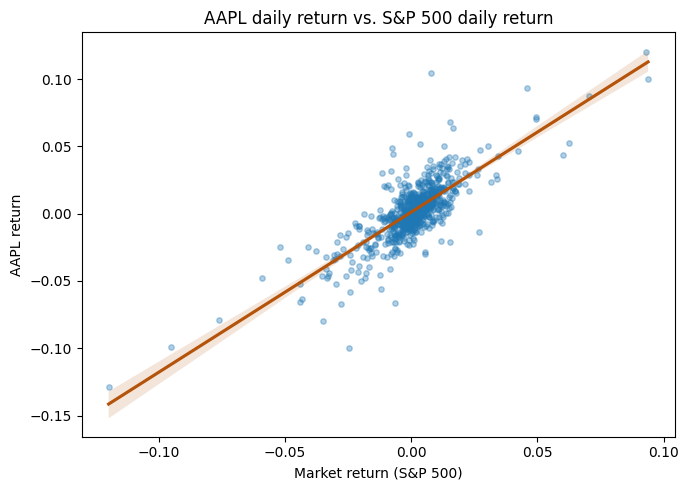

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=aapl_full, x="MktReturn", y="Returns",
    scatter_kws={"alpha": 0.35, "s": 15}, line_kws={"color": "#b45309"}, ax=ax,
)
ax.set_title("AAPL daily return vs. S&P 500 daily return")
ax.set_xlabel("Market return (S&P 500)")
ax.set_ylabel("AAPL return")
plt.tight_layout()
plt.show()

### Multiple regression: adding a second predictor

A **multiple regression** adds more predictors to explain $y$:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \varepsilon$$

Each $\beta_i$ now has a more careful interpretation: the expected change in $y$ for a one-unit
change in $x_i$, **holding all other predictors in the model constant**. That "holding constant"
is what makes multiple regression powerful &mdash; and, as we'll see next block, also easy to
misuse.

Let's ask: does GOOG's return explain AAPL's return, *beyond* what the overall market already
explains? First reshape the data so each date is one row, with a column per ticker.

<small>Why reshape now and not before? The simple regression only needed one ticker's returns
plus `MktReturn`, and both already sit in the same row. Now we need AAPL's *and* GOOG's returns
for the *same date* side by side &mdash; but in the long format, those are on two different rows
(different `Ticker Symbol` values). Pivoting turns each ticker into its own column so one row
holds both.</small>

In [11]:
wide = df.pivot(index="Names Date", columns="Ticker Symbol", values="Returns")
wide["MktReturn"] = df.groupby("Names Date")["MktReturn"].mean()
wide = wide.dropna()
wide.head()

Ticker Symbol,AAPL,AMZN,GOOG,NFLX,MktReturn
Names Date,,,,,
2018-01-02,0.017905,0.016708,0.017775,0.047458,0.008303
2018-01-03,-0.000174,0.012775,0.016413,0.019794,0.006399
2018-01-04,0.004645,0.004476,0.003621,0.002829,0.004029
2018-01-05,0.011385,0.016163,0.014571,0.021203,0.007034
2018-01-08,-0.003714,0.014425,0.004273,0.009810,0.001662


In [12]:
model_multi = smf.ols("AAPL ~ GOOG + MktReturn", data=wide).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     659.9
Date:                Tue, 15 Sep 2026   Prob (F-statistic):          2.68e-166
Time:                        17:48:36   Log-Likelihood:                 2192.4
No. Observations:                 756   AIC:                            -4379.
Df Residuals:                     753   BIC:                            -4365.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0011      0.000      2.241      0.0

Both `GOOG` and `MktReturn` come back significant: even after controlling for the overall market,
AAPL and GOOG still move together somewhat &mdash; plausibly because both are large tech stocks
exposed to similar sector-specific news that the broad S&P 500 doesn't fully capture.

A caution: `GOOG` and `MktReturn` are themselves correlated (both are influenced by the same
broad market swings), which is exactly the situation called **multicollinearity**. It doesn't bias
the coefficients, but it does inflate their standard errors, making it harder to pin down each
variable's *individual* effect precisely. Worth checking whenever you add several related
predictors:

In [13]:
wide[["GOOG", "MktReturn"]].corr()

Ticker Symbol,GOOG,MktReturn
Ticker Symbol,,
GOOG,1.000000,0.799495
MktReturn,0.799495,1.000000


<span style="color:#b45309">**Exercise 2: Estimate another stock's beta**</span>

Run a simple regression of NFLX's `Returns` on `MktReturn` (you can filter `df` the same way as for
AAPL, or use the `wide` DataFrame). Report NFLX's beta and intercept, say whether the beta is
statistically significant, and compare NFLX's $R^2$ to AAPL's &mdash; which stock's daily moves are
better explained by the market?

Try it in the cell below, then check the answer notebook (`Session 3a - Exercise Answers.ipynb`).

In [14]:
# your code here


## <span style="color:#1e3a8a">Looking ahead</span>

Every coefficient we produced today came with a p-value, so it's tempting to read "significant" as
"real effect." But a regression coefficient is a *statement about association in this sample* &mdash;
exactly like the correlation test back in Part 1. GOOG's return "explaining" AAPL's return doesn't
mean trading GOOG moves AAPL's price.

Next block: what a regression coefficient can and can't tell you about *cause and effect*, and why
the variables you choose to control for can make a coefficient more honest &mdash; or a great deal
less.